In [1]:
# Radon Forecast — XGBoost с подбором гиперпараметров через Optuna

# Установка зависимостей
!pip install -q xgboost optuna scikit-learn matplotlib pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.3 MB/s eta 0:00:00


In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json

In [3]:
# --- Загрузка и подготовка данных ---
def load_and_prepare_data(filepath):
    print("Загрузка и подготовка данных...")
    df = pd.read_csv(filepath, sep=';', decimal=',', encoding='latin-1')
    df['Datetime'] = pd.to_datetime(df['Datetime'], format="%d.%m.%Y %H:%M")
    df.set_index('Datetime', inplace=True)
    df = df.sort_index().interpolate(method='time')
    return df

In [4]:
def split_and_scale_data(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    train_size = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns

In [5]:
# --- Оптимизация гиперпараметров ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }
    model = xgb.XGBRegressor(**params, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error')
    return -scores.mean()

In [6]:
# --- Основной скрипт ---
df = load_and_prepare_data("/content/data.csv")
TARGET = 'Radon (Bq.m3)'
X_train_scaled, X_test_scaled, y_train, y_test, feature_names = split_and_scale_data(df, TARGET)

Загрузка и подготовка данных...


In [7]:
print("Настройка гиперпараметров XGBoost через Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2025-05-05 11:57:34,421] A new study created in memory with name: no-name-6e24ccaf-40a3-442a-a508-5facd6004b85


Настройка гиперпараметров XGBoost через Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-05-05 11:57:36,927] Trial 0 finished with value: 11726.676646756243 and parameters: {'n_estimators': 101, 'max_depth': 10, 'learning_rate': 0.10578893784522464, 'subsample': 0.8517982478950052, 'colsample_bytree': 0.5772461671422844, 'gamma': 1.069009672488583, 'reg_lambda': 0.9194437487996102}. Best is trial 0 with value: 11726.676646756243.
[I 2025-05-05 11:57:39,316] Trial 1 finished with value: 11103.324181675978 and parameters: {'n_estimators': 235, 'max_depth': 3, 'learning_rate': 0.09350496676297902, 'subsample': 0.9963548875669778, 'colsample_bytree': 0.7337673915556906, 'gamma': 0.31846789141332543, 'reg_lambda': 1.450644647249845}. Best is trial 1 with value: 11103.324181675978.
[I 2025-05-05 11:57:41,203] Trial 2 finished with value: 11770.497111128532 and parameters: {'n_estimators': 284, 'max_depth': 4, 'learning_rate': 0.10561560259277816, 'subsample': 0.5106457307892264, 'colsample_bytree': 0.9814120298788713, 'gamma': 1.3551785449177167, 'reg_lambda': 0.01179618

In [8]:
best_params = study.best_params
print("Лучшие параметры:", best_params)
model = xgb.XGBRegressor(**best_params, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

Лучшие параметры: {'n_estimators': 52, 'max_depth': 7, 'learning_rate': 0.01480309288824474, 'subsample': 0.7029688658111513, 'colsample_bytree': 0.7870764763848327, 'gamma': 4.104842444900502, 'reg_lambda': 0.023475536257135263}


In [9]:
# --- Метрики и сохранение ---
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

MSE: 78252743.26, MAE: 7140.92, R2: -0.06


In [10]:
with open("xgboost_results.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "test_mse": mse,
        "test_mae": mae,
        "test_r2": r2
    }, f, indent=4)

study.trials_dataframe().to_csv("xgboost_trials.csv", index=False)

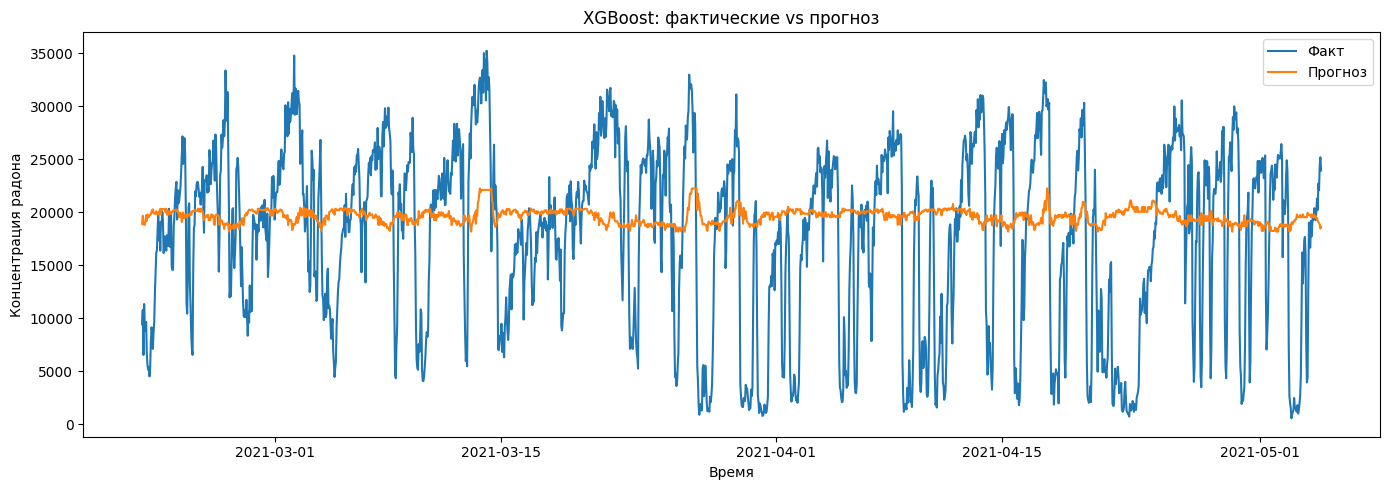

In [11]:
# --- Визуализация ---
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Факт')
plt.plot(y_test.index, y_pred, label='Прогноз')
plt.title("XGBoost: фактические vs прогноз")
plt.xlabel("Время")
plt.ylabel("Концентрация радона")
plt.legend()
plt.tight_layout()
plt.savefig("xgboost_forecast.jpeg")
plt.show()

<Figure size 20000x10000 with 0 Axes>

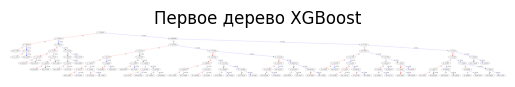

In [14]:
plt.figure(figsize=(200, 100))
xgb.plot_tree(model, num_trees=0)
plt.title("Первое дерево XGBoost")
plt.savefig("xgboost_tree.jpeg")
plt.show()

<Figure size 1000x600 with 0 Axes>

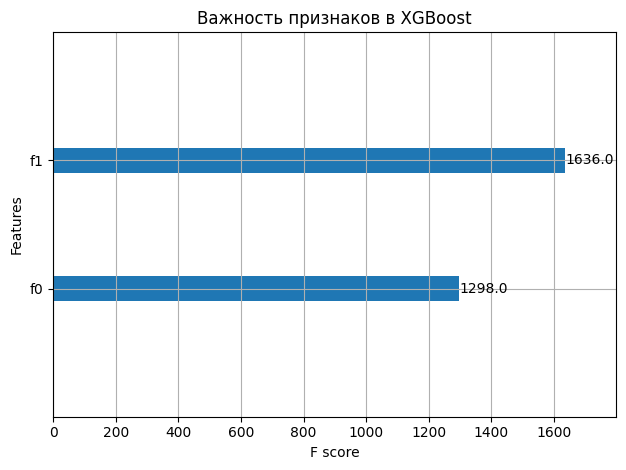

In [13]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model)
plt.title("Важность признаков в XGBoost")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.jpeg")
plt.show()